# Kinetic Monte Carlo


:::{admonition} **What you will learn**
:class: info

- Why **Metropolis Monte Carlo** samples equilibrium but cannot give real-time dynamics, and what kinetic Monte Carlo (KMC) adds.
- **Continuous-time Markov chains**, propensities, and the waiting-time distribution $P(\tau) = a_0 e^{-a_0 \tau}$.
- The **Gillespie (direct) algorithm** — a rejection-free SSA that produces statistically exact trajectories of any chemical reaction network.
- Three escalating examples: a **two-state isomerization**, an **A $\to$ B $\to$ C chain**, and **Lotka–Volterra predator–prey**, which exhibits stochastic oscillations invisible to the deterministic ODE.

:::


## From Metropolis to KMC

Metropolis MCMC generates a Markov chain whose *stationary distribution* is the Boltzmann weight. The sequence of states obeys detailed balance but the "time" between two Metropolis steps has no physical meaning — it is just an iteration counter. If you need to ask **"how long does this process take?"** or **"what is the waiting time before the first event?"**, Metropolis will not answer you.

Kinetic Monte Carlo works instead with **rates**. Each elementary process $i$ is assigned a rate (propensity) $a_i$ with units of inverse time. The algorithm then produces an *exact* realization of the continuous-time Markov chain defined by those rates: a sequence of states together with the physical times at which they occur. KMC is what you use to study reaction kinetics, surface growth, nucleation, epidemics, protein folding pathways, and any other process where the *dynamics* matter, not just the equilibrium distribution.


## Continuous-time Markov chains

A state $x$ evolves by discrete jumps $x \to x + \nu_i$, each occurring at rate $a_i(x)$. Two facts follow from the memoryless property of the exponential distribution:

1. **Total rate.** When the system is in state $x$, the total rate of leaving is
   $$ a_0(x) \;=\; \sum_i a_i(x). $$
2. **Waiting-time distribution.** The time $\tau$ until the *next* event (of any type) is exponentially distributed:
   $$ P(\tau \mid x) \;=\; a_0(x)\, e^{-a_0(x)\,\tau}. $$

Given that an event happens, it is reaction $i$ with probability $a_i(x)/a_0(x)$. These two ingredients are all you need.


:::{admonition} **Gillespie direct algorithm**
:class: tip

Repeat until $t > t_{\max}$:

1. Compute all propensities $a_i(x)$ and the total rate $a_0 = \sum_i a_i$.
2. Draw two independent uniform random numbers $u_1, u_2 \in (0,1)$.
3. Advance time: $\tau = -\ln(u_1)/a_0$, so $t \leftarrow t + \tau$.
4. Choose reaction $j$ as the smallest integer for which $\sum_{k \le j} a_k \ge u_2\, a_0$.
5. Update the state: $x \leftarrow x + \nu_j$.

That's it. There are no rejections and no timestep to tune — each iteration advances the clock by the physically correct amount, and the recorded $(t_n, x_n)$ trajectory is a statistically exact sample of the master equation.
:::


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

plt.rcParams.update({'figure.dpi': 110})

def gillespie(x0, propensities, stoich, t_max, rng=None, max_events=10_000_000):
    '''Gillespie direct-method SSA.

    Parameters
    ----------
    x0           : initial state vector (ints)
    propensities : callable x -> array of rates a_i(x)
    stoich       : (n_reactions, n_species) state-change vectors nu_i
    t_max        : simulation end time
    rng          : numpy Generator (default: fresh default_rng())

    Returns
    -------
    t : (n_events+1,) times (starts at 0)
    x : (n_events+1, n_species) state trajectory
    '''
    if rng is None:
        rng = np.random.default_rng()
    stoich = np.asarray(stoich, dtype=int)
    x      = np.array(x0, dtype=int)
    ts     = [0.0]
    xs     = [x.copy()]
    t      = 0.0

    for _ in range(max_events):
        a  = np.asarray(propensities(x), dtype=float)
        a0 = a.sum()
        if a0 <= 0:
            break
        tau = -np.log(rng.random()) / a0
        t  += tau
        if t > t_max:
            break
        j = np.searchsorted(np.cumsum(a), rng.random() * a0)
        x = x + stoich[j]
        ts.append(t)
        xs.append(x.copy())
    return np.array(ts), np.array(xs)


## Example 1 — Two-state isomerization $A \rightleftharpoons B$

The simplest nontrivial case: a single molecule (or a population of $N$ molecules) that flips between two states with forward rate $k_f$ and backward rate $k_b$.

$$ \frac{d\langle A \rangle}{dt} \;=\; -k_f\, A + k_b\, B, \qquad A + B = N. $$

The deterministic solution is a single exponential approach to the equilibrium $\langle A \rangle_{\text{eq}} = N\, k_b / (k_f + k_b)$. KMC reproduces this *on average* and on top gives us the fluctuations around it.


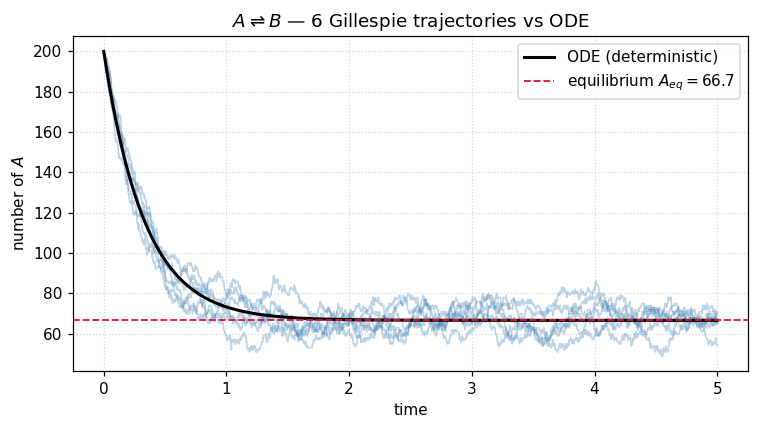

In [2]:
# Two-state isomerization
k_f, k_b, N0 = 2.0, 1.0, 200
stoich_2state = np.array([[-1, +1],    # A -> B
                          [+1, -1]])   # B -> A

def props_2state(x):
    A, B = x
    return np.array([k_f * A, k_b * B])

rng = np.random.default_rng(0)
n_traj = 6
trajectories = [gillespie([N0, 0], props_2state, stoich_2state, t_max=5.0, rng=rng)
                for _ in range(n_traj)]

# Deterministic ODE reference
def ode(y, t):
    A, B = y
    return [-k_f * A + k_b * B,
            +k_f * A - k_b * B]

t_ode = np.linspace(0, 5, 400)
y_ode = odeint(ode, [N0, 0], t_ode)
A_eq  = N0 * k_b / (k_f + k_b)

fig, ax = plt.subplots(figsize=(7, 4))
for ts, xs in trajectories:
    ax.step(ts, xs[:, 0], where='post', color='steelblue', alpha=0.35, lw=1)
ax.plot(t_ode, y_ode[:, 0], 'k-', lw=2, label='ODE (deterministic)')
ax.axhline(A_eq, color='crimson', ls='--', lw=1.2, label=f'equilibrium $A_{{eq}} = {A_eq:.1f}$')
ax.set_xlabel('time'); ax.set_ylabel('number of $A$')
ax.set_title(f'$A \\rightleftharpoons B$ — {n_traj} Gillespie trajectories vs ODE')
ax.legend(); ax.grid(True, ls=':', alpha=0.5)
plt.tight_layout()
plt.show()


Each staircase is an individual KMC realization. The smooth black curve is the ODE limit — it coincides with the *ensemble average* of the staircases. Notice two things:

- The waiting times between jumps at the start are tiny (because $a_0$ is large when many $A$ molecules are still available to react), and grow as the population approaches equilibrium.
- The fluctuations around equilibrium have amplitude $\sim\sqrt{N}$, the hallmark of demographic noise.


## Example 2 — Chain reaction $A \to B \to C$

A prototypical two-step kinetic scheme: $A$ is converted to an intermediate $B$ which in turn decays to product $C$. If the second step is slow, $B$ builds up and then drains; if it is fast, $B$ never accumulates. KMC lets us see both the mean trajectory and the fluctuations for each species with no extra code.


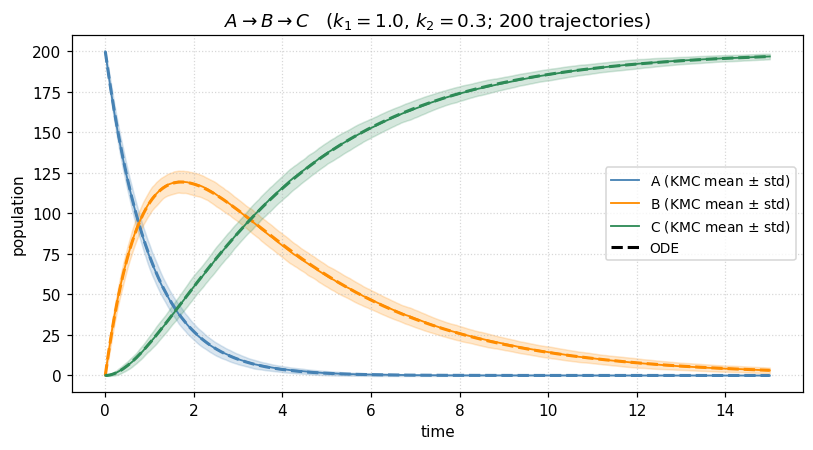

In [3]:
# A -> B -> C
k1, k2 = 1.0, 0.3
stoich_chain = np.array([[-1, +1,  0],    # A -> B
                         [ 0, -1, +1]])   # B -> C

def props_chain(x):
    A, B, C = x
    return np.array([k1 * A, k2 * B])

# Ensemble
rng = np.random.default_rng(42)
M   = 200
t_grid = np.linspace(0, 15, 300)
N0_chain = 200

ensemble = np.zeros((M, len(t_grid), 3))
for m in range(M):
    ts, xs = gillespie([N0_chain, 0, 0], props_chain, stoich_chain, t_max=15.0, rng=rng)
    # project the piecewise-constant trajectory onto the common grid
    idx = np.searchsorted(ts, t_grid, side='right') - 1
    idx = np.clip(idx, 0, len(ts) - 1)
    ensemble[m] = xs[idx]

mean_traj = ensemble.mean(axis=0)
std_traj  = ensemble.std(axis=0)

# ODE for comparison
def ode_chain(y, t):
    A, B, C = y
    return [-k1 * A, k1 * A - k2 * B, k2 * B]
y_chain = odeint(ode_chain, [N0_chain, 0, 0], t_grid)

labels  = ['A', 'B', 'C']
colors  = ['steelblue', 'darkorange', 'seagreen']
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for k in range(3):
    ax.fill_between(t_grid,
                    mean_traj[:, k] - std_traj[:, k],
                    mean_traj[:, k] + std_traj[:, k],
                    color=colors[k], alpha=0.2)
    ax.plot(t_grid, mean_traj[:, k], color=colors[k], lw=1.2,
            label=f'{labels[k]} (KMC mean $\\pm$ std)')
    ax.plot(t_grid, y_chain[:, k], color=colors[k], lw=2, ls='--')
ax.plot([], [], color='k', lw=2, ls='--', label='ODE')
ax.set_xlabel('time'); ax.set_ylabel('population')
ax.set_title(f'$A \\to B \\to C$   ($k_1 = {k1}$, $k_2 = {k2}$; {M} trajectories)')
ax.legend(fontsize=9); ax.grid(True, ls=':', alpha=0.5)
plt.tight_layout()
plt.show()


The intermediate $B$ overshoots and drains — a textbook transient. The stochastic band is narrow because $N_0 = 200$ is large, but it is nonzero, and for small populations it dominates. That is the regime where KMC becomes indispensable.


## Example 3 — Lotka–Volterra: where stochasticity *changes the answer*

Now a system where the deterministic limit and the stochastic simulation make qualitatively different predictions. Lotka–Volterra dynamics (prey $X$, predator $Y$) with three reactions:

| reaction | rate | meaning |
|---|---|---|
| $X \to 2X$   | $\alpha X$      | prey birth |
| $X + Y \to 2Y$ | $\beta X Y$   | predation |
| $Y \to \emptyset$ | $\gamma Y$ | predator death |

The ODE has a family of closed orbits — a neutral center — for any initial condition. Stochastic simulation reveals that those orbits are **structurally unstable**: demographic fluctuations drive the system into the axes, and one species (usually the predator) goes extinct in finite time. This kind of noise-driven extinction is completely absent from the mean-field ODE.


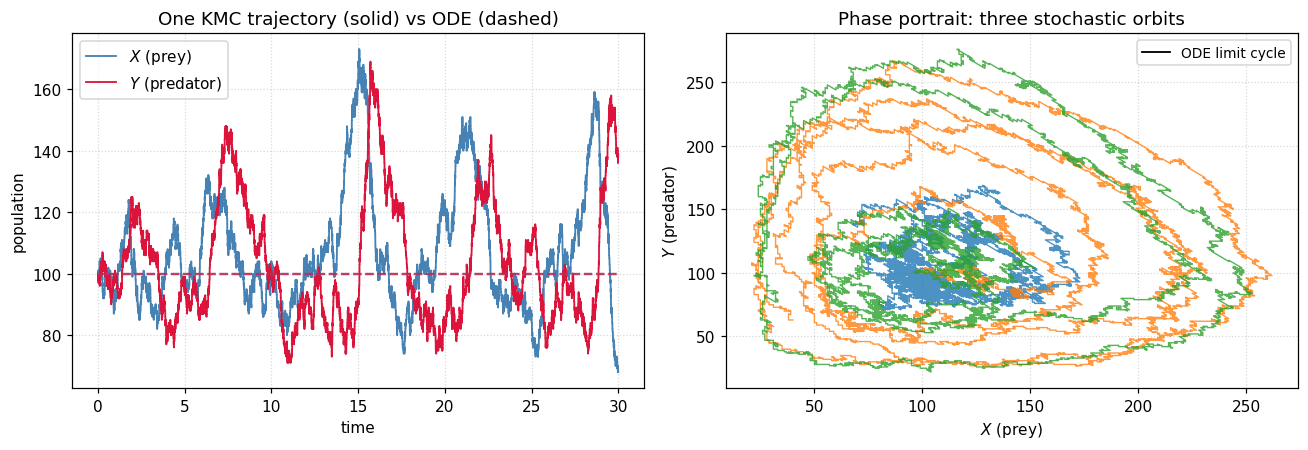

In [4]:
# Lotka-Volterra
alpha, beta, gamma = 1.0, 0.01, 1.0
stoich_lv = np.array([[+1,  0],   # X -> 2X (prey birth)
                      [-1, +1],   # X + Y -> 2Y
                      [ 0, -1]])  # Y -> 0

def props_lv(x):
    X, Y = x
    return np.array([alpha * X,
                     beta  * X * Y,
                     gamma * Y])

# Deterministic limit
def ode_lv(y, t):
    X, Y = y
    return [alpha * X - beta * X * Y,
            beta  * X * Y - gamma * Y]
t_ode_lv = np.linspace(0, 30, 600)
y_ode_lv = odeint(ode_lv, [100, 100], t_ode_lv)

# Three stochastic trajectories from the same initial condition
rng = np.random.default_rng(7)
trajs_lv = [gillespie([100, 100], props_lv, stoich_lv, t_max=30.0, rng=rng)
            for _ in range(3)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# (a) time series of one realization
ts, xs = trajs_lv[0]
axes[0].step(ts, xs[:, 0], where='post', color='steelblue', lw=1.2, label='$X$ (prey)')
axes[0].step(ts, xs[:, 1], where='post', color='crimson',   lw=1.2, label='$Y$ (predator)')
axes[0].plot(t_ode_lv, y_ode_lv[:, 0], color='steelblue', lw=1.5, ls='--', alpha=0.7)
axes[0].plot(t_ode_lv, y_ode_lv[:, 1], color='crimson',   lw=1.5, ls='--', alpha=0.7)
axes[0].set_xlabel('time'); axes[0].set_ylabel('population')
axes[0].set_title('One KMC trajectory (solid) vs ODE (dashed)')
axes[0].legend(); axes[0].grid(True, ls=':', alpha=0.5)

# (b) phase portrait
axes[1].plot(y_ode_lv[:, 0], y_ode_lv[:, 1], 'k-', lw=1.2, label='ODE limit cycle')
for ts, xs in trajs_lv:
    axes[1].plot(xs[:, 0], xs[:, 1], lw=0.9, alpha=0.8)
axes[1].set_xlabel('$X$ (prey)'); axes[1].set_ylabel('$Y$ (predator)')
axes[1].set_title('Phase portrait: three stochastic orbits')
axes[1].grid(True, ls=':', alpha=0.5)
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()


The stochastic orbits wander in and out of the ODE cycle; some drift outward until a fluctuation takes the predator count to zero, at which point the prey grow unchecked forever. The deterministic model never sees this — it has a conserved quantity that keeps every orbit closed. Demographic noise breaks that conservation law, and KMC is the right tool to study it.


## Takeaways

- **KMC = exact simulation of a continuous-time Markov chain.** The state evolves by discrete jumps at times drawn from the correct exponential waiting-time distribution.
- **One algorithm, many problems.** Change only `propensities` and `stoich`; the Gillespie kernel is reaction-network agnostic.
- **Stochastic $\ne$ deterministic when $N$ is small or near an instability.** Intermediates, extinctions, nucleation events — all demand KMC.
- **Scaling.** Direct Gillespie is $\mathcal{O}(\text{events} \times \text{reactions})$. For large networks use the next-reaction method or $\tau$-leaping; for spatial problems use lattice KMC.


## Problems

1. **Equilibrium fluctuations.** Run the two-state model to long times and histogram $A(t)$ in the stationary regime. Verify that the mean matches $A_{eq}$ and the variance matches the binomial expectation $N\, p\, (1-p)$ with $p = k_b/(k_f + k_b)$.

2. **First-passage times.** Modify the two-state code to record the time of the first $A \to B$ event. Histogram this time over many trajectories and compare with the exponential prediction $P(\tau) = k_f N_0\, e^{-k_f N_0 \tau}$.

3. **Chain reaction extremes.** Rerun the $A \to B \to C$ example with (a) $k_1 \gg k_2$ and (b) $k_1 \ll k_2$. Explain why the intermediate $B$ accumulates in one case and not the other. Confirm that when $k_1 \ll k_2$ the total rate is dominated by the slow step.

4. **Lotka-Volterra extinction statistics.** Simulate 500 Lotka-Volterra trajectories starting at $(X, Y) = (100, 100)$. Record the extinction time (first time either species hits zero) and plot the distribution. Does it look exponential? How does the mean extinction time scale with the initial population?

5. **Gillespie vs Metropolis on Ising.** For the 2D Ising model at $T$ slightly below $T_c$, implement a **Glauber KMC** update: the rate of flipping spin $i$ is $w_i = 1/(1 + e^{\beta \Delta E_i})$. Compare the time evolution of the magnetization with the step counter of a Metropolis simulation. Which one has physical time units?
